In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
base_path = Path(".") 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

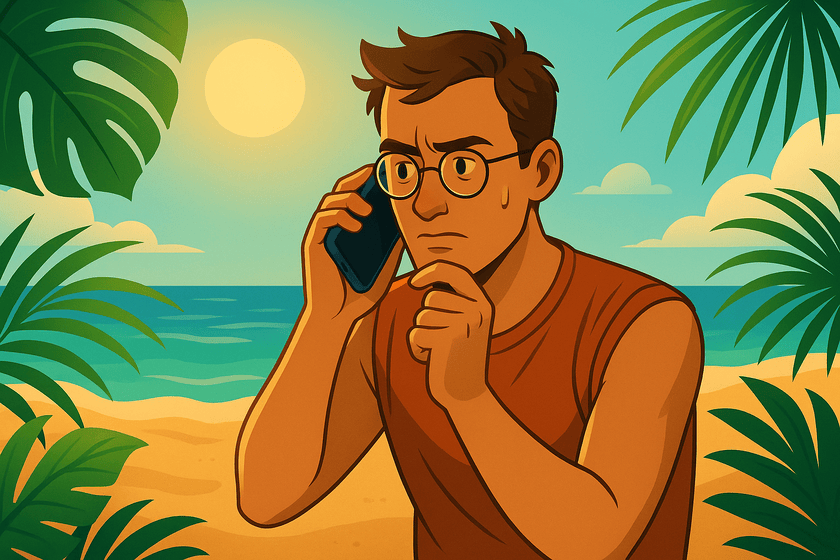

(*AI-generated image*)

In [134]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [135]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Kolumna Survived jest kolumną docelową. Ofiar jest więcej natomiast nie ma mocnej dominacji jednej klasy nad drugą.

In [136]:
titanic_df.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


Dla wygody wyświetlam pierwsze kilka wierszy żeby zobaczyć jak wyglądają dane

In [137]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [138]:
def get_percentage_missing(df, axis=0):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

missing = get_percentage_missing(titanic_df)
print(missing)

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


Zgodnie z wynikiem można zobaczyć że tylko niektóre kolumny mają brakujące dane. Kolumna Cabin ma dość dużo wartości brakujących i nie jest aż tak istotna. Najlepszym rozwiązaniem tutaj będzie ją usunąc.

In [139]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket', 'Cabin'])

Usuwam nieistotne kolumny w kontekście problemu

In [140]:
age_med = titanic_df['Age'].median()
fare_med = titanic_df['Fare'].median()
embarked_mode = titanic_df['Embarked'].mode()[0]

Numeryczne będe uzupełniał medianą a kategorialne najczęstszą wartością (mode)

In [141]:
titanic_df['Age'] = titanic_df['Age'].fillna(age_med)
titanic_df['Fare'] = titanic_df['Fare'].fillna(fare_med)
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)

In [142]:
check_missing = get_percentage_missing(titanic_df)
print(check_missing)

Series([], dtype: float64)


Sprawdzenie czy nie ma już kolumn które warto uzupełnić

In [143]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'], bins=bins, labels=labels)

Pierwszą nową kolumną będzie AgeGroup - na podstawie wieku przypisuję grupę wiekową

In [144]:
titanic_df['IsWomanOrChild'] = ((titanic_df['Sex'] == 'female') | (titanic_df['Age'] < 18)).astype(int)

Drugą kolumną będzie flaga pokazująca czy dana osoba jest dzieckiem czy kobietą

## <b>Wizualizacja kolumn</b>

### <i>Kategorialne</i>

Najpierw zostanie dodana funkcja która wizualizuje cechy kategorialne

In [145]:
def plot_categorical_column(df, column_name):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

Cecha <b>Survived</b>

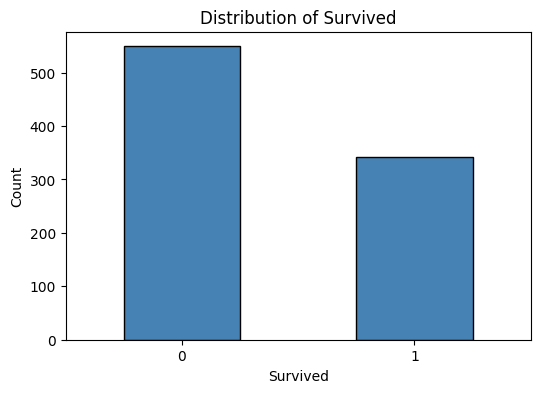

In [146]:
plot_categorical_column(titanic_df,"Survived")

Cecha <b>Sex</b>

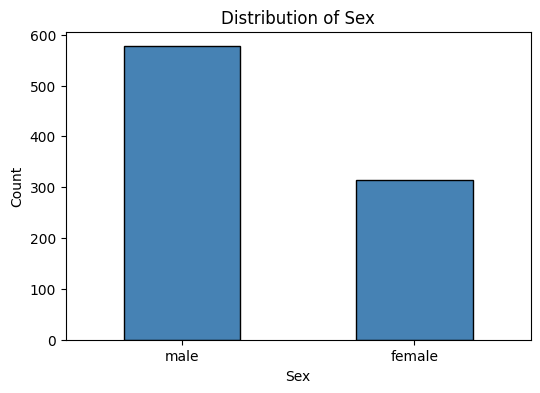

In [147]:
plot_categorical_column(titanic_df,"Sex")

Cecha <b>Pclass</b>

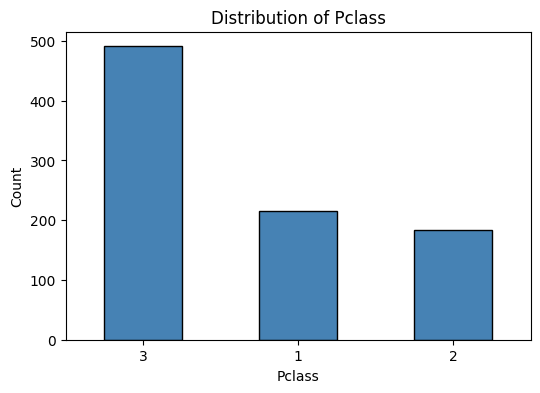

In [148]:
plot_categorical_column(titanic_df,"Pclass")

Cecha <b>Parch</b>

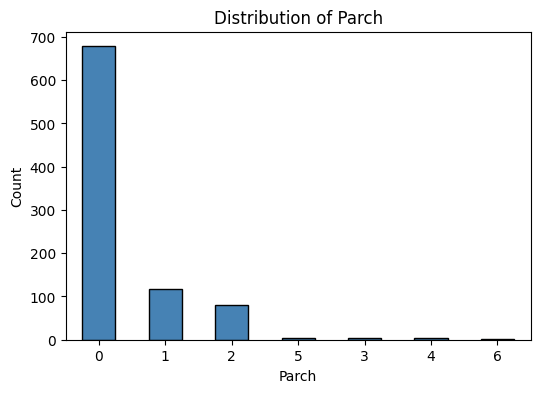

In [149]:
plot_categorical_column(titanic_df,"Parch")

Cecha <b>Embarked</b>

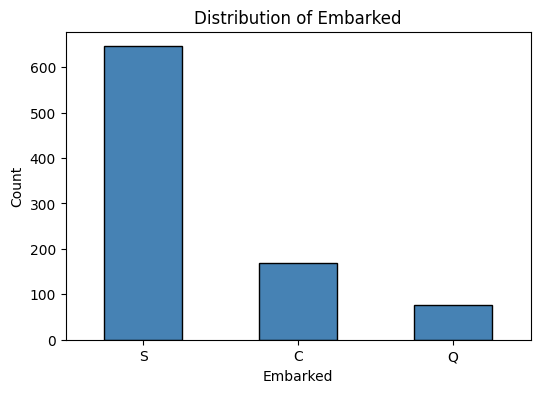

In [150]:
plot_categorical_column(titanic_df,"Embarked")

Cecha <b>SibSp</b>

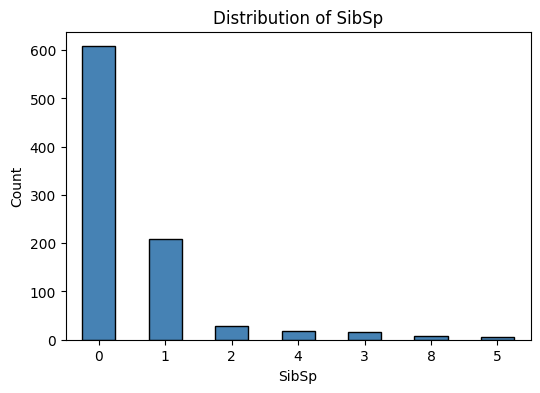

In [151]:
plot_categorical_column(titanic_df, "SibSp")

Cecha <b>AgeGroup</b>

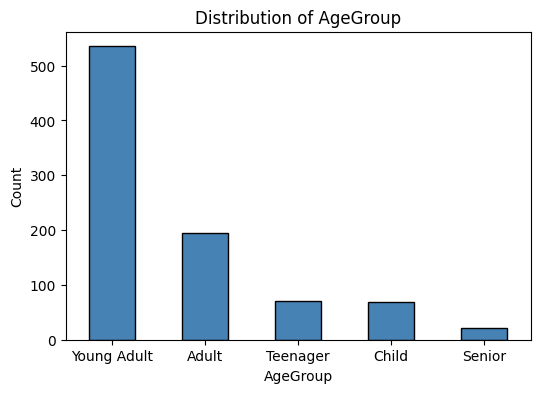

In [152]:
plot_categorical_column(titanic_df,"AgeGroup")

Cecha <b>IsWomanOrChild</b>

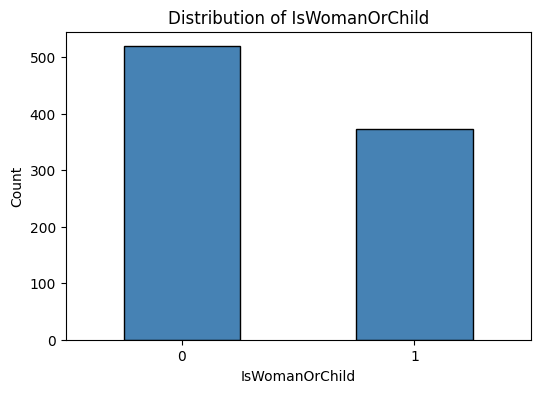

In [153]:
plot_categorical_column(titanic_df,"IsWomanOrChild")

### <i>Numeryczne</i>

Najpierw zostaną dodane funkcje do wizualizacji danych numerycznych

##### <b>Histogram</b>

In [154]:
def plot_numeric_histogram(df, column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

##### <b>BoxPlot</b>

In [155]:
def plot_numeric_boxplot(df, column_name):
    data = df[column_name].dropna()
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(data,color='steelblue')
    plt.title(f"Boxplot of {column_name}")
    plt.xlabel(column_name)
    plt.tight_layout()
    plt.show()

Cecha <b>Fare</b>

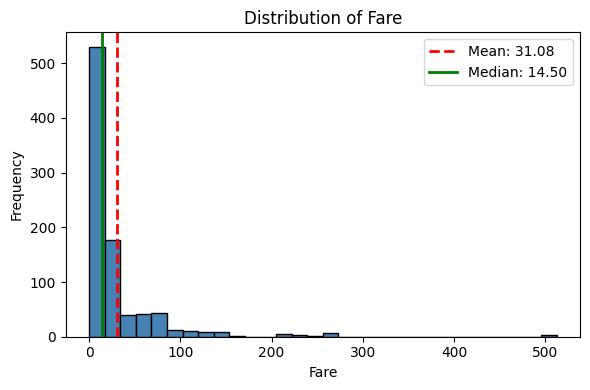

In [156]:
plot_numeric_histogram(titanic_df,"Fare")

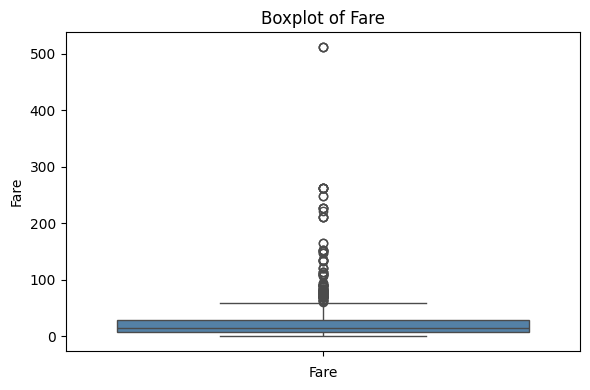

In [157]:
plot_numeric_boxplot(titanic_df, "Fare")

Cecha <b>Age</b>

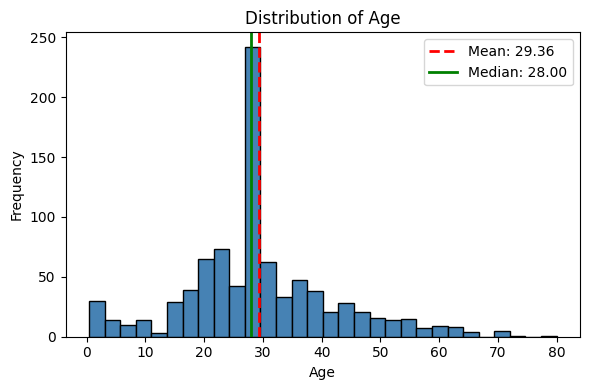

In [158]:
plot_numeric_histogram(titanic_df,"Age")

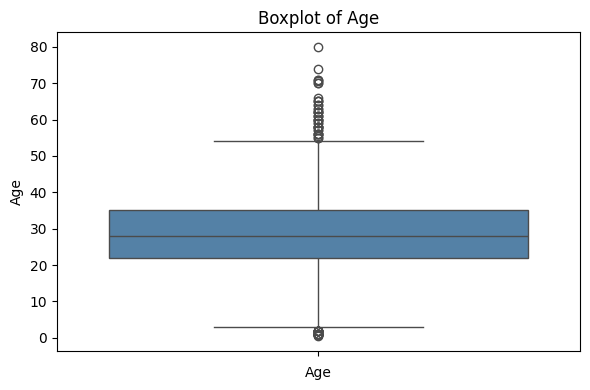

In [159]:
plot_numeric_boxplot(titanic_df,"Age")

## <b>Kodowanie kolumn kategorialnych</b>

Kategorialny kolumny tekstowe to: Sex, Embarked oraz AgeGroup

Cechy Sex oraz Embarked mają kategorie które są od siebie niezależne - czyli nie mają żadnego porządku. W tym celu najlepiej je zakodować za pomocą One-Hot Encoding

In [160]:
titanic_df = pd.get_dummies(data=titanic_df, columns=['Sex', 'Embarked'], dtype=np.int32)

Cecha AgeGroup natomiast ma hierarchię w kontekście ratowania ponieważ najpierw ratujemy dzieci, nastolatków, młodzież, starców a na końcu dorosłych. W tym celu warto wykorzystać Ordinal Encoding

In [161]:
age_group = {
    "Child": 1,
    "Teenager": 2,
    "Young Adult": 3,
    "Senior": 4,
    "Adult": 5
}

titanic_df['AgeGroup']=titanic_df['AgeGroup'].map(age_group)

Sprawdzenie kodowania

In [162]:
titanic_df.head(3)

,Survived,Pclass,Age,SibSp,Parch,Fare,AgeGroup,IsWomanOrChild,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0,3,22.0,1,0,7.2500,3,0,0,1,0,0,1
2,1,1,38.0,1,0,71.2833,5,1,1,0,1,0,0
3,1,3,26.0,0,0,7.9250,3,1,1,0,0,0,1


## <b>Podsumowanie (odp na pytania)</b>

1. Kolumna Ticket zawierająca numer biletu oraz Name nie mają znaczenia w kontekście rozpatrywanego problemu. Kolumna Cabin ma ogromne braki i zresztą też nie jest jakoś mocno istotna dlatego została usunięta.

2. Dla cech kategorialnych uzupełniłem dane metodą najczęściej występującej wartości a dla numerycznych zastosowałem medianę

3. Wszystkie dane numeryczne są asymetryczne. Jeśli chodzi o kategorialne to również nie są zbalansowane i jedna wartość dominuje nad innymi (co widać z wykresów).

4. Predykowaną klasą jest zmienna <b><i>Survived</i></b>